In [1]:
import os
from typing import Literal, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
from rdp import rdp

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

from lttb import downsample

from lstm_network import LSTMModel, LSTMTrainer

(14461, 7)


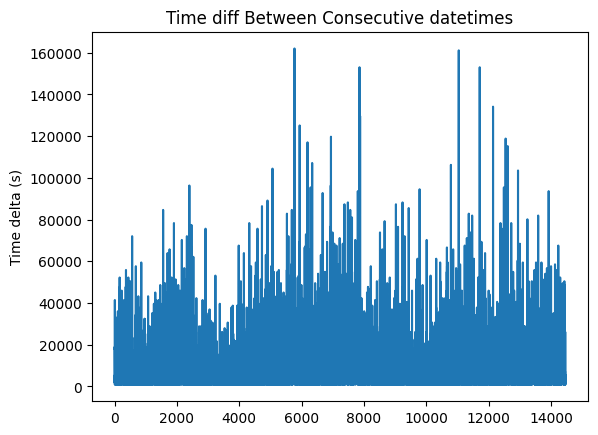

In [2]:
def plot_time_deltas(df: pd.DataFrame, time_col: str) -> None:
    """Calculate time diff between consecutive datetime entries in the specified column,
    and plot these time deltas"""
    df[time_col]= pd.to_datetime(df[time_col])
    diffs       = df[time_col].diff().dropna()
    plt.plot(diffs.dt.total_seconds())
    plt.ylabel('Time delta (s)')
    plt.title('Time diff Between Consecutive datetimes')
    plt.show()

datasets = {"GDELT_USA_LAB":      {"path": "Time-IMM/GDELT_USA_LAB",       "time_col": "date_time", "y": ["AvgTone"]},
            "ClusterTrace_707":   {"path": "Time-IMM/ClusterTrace_707",    "time_col": "date_time", "y": ["cpu", "memory"]},
            "EPA_air_los_angeles":{"path": "Time-IMM/EPA_air_los_angeles", "time_col": "date_time", "y": ["ozone"]},
            "FNSPID_EXPE":        {"path": "Time-IMM/FNSPID_EXPE",         "time_col": "date_time", "y": ["adj close"]},
            "ILINet":             {"path": "Time-IMM/ILINet",              "time_col": "date_time", "y": ["TOTAL PATIENTS"]},
            "repohealth_facebook":{"path": "Time-IMM/repohealth_facebook", "time_col": "date_time", "y": ["new_issues"]},
            "studentlife_fc7337": {"path": "Time-IMM/studentlife_fc7337",  "time_col": "date_time", "y": ["sleep_duration"]},
            "power_consumption":  {"path": "power_consumption",            "time_col": "Datetime",  "y": ["PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]},
            "appliances_energy":  {"path": "appliances_energy",            "time_col": "date",      "y": ["rv1", "rv2"]}}

desired_dataset= "GDELT_USA_LAB"
df             = pd.read_csv(f"../public_datasets/{datasets[desired_dataset]['path']}.csv")
time_col_name  = datasets[desired_dataset]["time_col"]
y_cols         = datasets[desired_dataset]["y"]

print(df.shape)
plot_time_deltas(df, time_col_name)


In [3]:
"""Pre-processing each dataset"""
try:
    if desired_dataset == "GDELT_USA_LAB":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ClusterTrace_707":
        pass
    elif desired_dataset == "EPA_air_los_angeles":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "FNSPID_EXPE":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ILINet":
        df.drop(["record_id"], axis=1, inplace=True)
        df = df.drop_duplicates(subset=['date_time'], keep='first').reset_index(drop=True) #some rows have same time
    elif desired_dataset == "repohealth_facebook":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "studentlife_fc7337":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "power_consumption":
        pass
    elif desired_dataset == "appliances_energy":
        pass
except Exception as e:
    pass

df = df.fillna(0)

In [ ]:
"""Applying metrics on X vs z"""

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Split your original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encode train/test via VAE
z_train = vae.encoder.predict(X_train)  # shape (num_samples, latent_dim)
z_test  = vae.encoder.predict(X_test)

# --- Predictor on raw X ---
model_X = LinearRegression()
model_X.fit(X_train.reshape(X_train.shape[0], -1), y_train)  # flatten if needed
y_pred_X = model_X.predict(X_test.reshape(X_test.shape[0], -1))

# --- Predictor on latent z ---
model_z = LinearRegression()
model_z.fit(z_train, y_train)
y_pred_z = model_z.predict(z_test)

# --- Metrics ---
def print_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

print_metrics(y_test, y_pred_X, "Predictor on X")
print_metrics(y_test, y_pred_z, "Predictor on z")


In [ ]:
class LTTBDownsampler:
    @staticmethod
    def downsample_using_lttb_union(df: pd.DataFrame, time_col: str, max_points_per_col: int) -> pd.DataFrame:
        """Downsample multivar timeseries using LTTB, keeping any point that is 'important' in at least 1 feature"""
        time        = df[time_col]
        kept_indices= set()

        is_time_col_datetime = pd.api.types.is_datetime64_any_dtype(time)
        if is_time_col_datetime:
            numeric_time = time.astype('int64')
        else:
            numeric_time = time

        # Apply LTTB to each col individually, then union indices
        for col in df.columns:
            if col == time_col:
                continue
            downsampled_col = downsample(np.column_stack((numeric_time.values, df[col].values)), max_points_per_col)
            
            # Find indices based on the original time column
            if is_time_col_datetime:
                # Reconstruct datetime from numeric_time to find indices
                downsampled_time = pd.to_datetime(downsampled_col[:, 0], unit='ns')
                col_indices      = df.index[df[time_col].isin(downsampled_time)]
            else:
                col_indices = df.index[df[time_col].isin(downsampled_col[:, 0])]
            kept_indices.update(col_indices)
        return df.loc[sorted(kept_indices)].reset_index(drop=True)

    @staticmethod
    def downsample_using_lttb_intersection(df: pd.DataFrame, time_col: str, max_points_per_col: int) -> pd.DataFrame:
        """Downsample multivar timeseries using LTTB, keeping only points important in all features (intersection)."""
        time = df[time_col]

        is_time_col_datetime = pd.api.types.is_datetime64_any_dtype(time)
        if is_time_col_datetime:
            numeric_time = time.astype('int64')
        else:
            numeric_time = time

        kept_indices = None

        for col in df.columns:
            if col == time_col:
                continue
            downsampled_col = downsample(np.column_stack((numeric_time.values, df[col].values)), max_points_per_col)
            
            if is_time_col_datetime:
                downsampled_time = pd.to_datetime(downsampled_col[:, 0], unit='ns')
                col_indices = set(df.index[df[time_col].isin(downsampled_time)])
            else:
                col_indices = set(df.index[df[time_col].isin(downsampled_col[:, 0])])

            if kept_indices is None:
                kept_indices = col_indices  # Initialize on first column
            else:
                kept_indices = kept_indices.intersection(col_indices)  # Intersection on others

        if kept_indices is None:
            # No columns other than time_col
            return df.copy()

        return df.loc[sorted(kept_indices)].reset_index(drop=True)

    @staticmethod
    def downsample_lttb_union_with_spikes(df: pd.DataFrame, time_col: str, max_points_per_col: int,
                                          spike_thresh: float = 4, spike_method: str = 'zscore') -> pd.DataFrame:
        """Downsample multivar timeseries using LTTB-union, but keep all 'spike' points
        'spike' = any point where abs(z-score) > spike_thresh for that col
        Works with numeric or datetime time col
        spike_method: "zscore" -> mean/std-based
                      "mad"    -> median/'Median Absolute Deviation'-based
        spike_thresh: threshold for spike detection (abs score > threshold)
                      ie. spike_thresh=4 means ~4 stdev away
        Works with numeric or datetime time col"""
        time        = df[time_col]
        kept_indices= set()
        MOD_ZSCORE  = 0.6745 # norm. constant
        # Convert datetime to numeric for LTTB if needed
        is_datetime = pd.api.types.is_datetime64_any_dtype(time)
        numeric_time= time.astype("int64") if is_datetime else time

        # 1: Spike detection
        for col in df.columns:
            if col == time_col:
                continue
            series = df[col].astype(float)

            if spike_method == "zscore":
                score  = (series - series.mean()) / series.std(ddof=0)
            elif spike_method == "mad":
                median = series.median()
                mad    = np.median(np.abs(series - median))
                if mad == 0:
                    continue  # avoid /0
                score = MOD_ZSCORE * (series - median) / mad
            else:
                raise ValueError("spike_method must be 'zscore' or 'mad'")
            spike_idx = df.index[np.abs(score) > spike_thresh]
            kept_indices.update(spike_idx)

        # 2: LTTB downsampling
        for col in df.columns:
            if col == time_col:
                continue
            downsampled = downsample(
                np.column_stack((numeric_time.values, df[col].values)), max_points_per_col)
            if is_datetime:
                down_t  = pd.to_datetime(downsampled[:, 0], unit="ns")
                col_idx = df.index[df[time_col].isin(down_t)]
            else:
                col_idx = df.index[df[time_col].isin(downsampled[:, 0])]
            kept_indices.update(col_idx)
        return df.loc[sorted(kept_indices)].reset_index(drop=True)

class OtherDownsamplers:
    @staticmethod
    def choose_rdp_epsilon(coords: np.ndarray, method: Literal["mad", "std", "fraction"] = "mad",
                        factor: float = 1.0, normalize_axes: bool = False) -> float:
        """Choose an RDP epsilon for coords (N x 2: [x, y])
        method:
        - "mad": epsilon = factor * MAD(y)
        - "std": epsilon = factor * std(y)
        - "fraction": epsilon = factor * (range(y))
        factor: multiplier (tune: 0.5-3 for mad/std, 1e-4-1e-2 for fraction)
        normalize_axes: if True, scale both axes to [0,1] before computing epsilon
        Returns: epsilon in the same units as coords (or normalized units if normalize_axes=True)"""
        if isinstance(coords, pd.DataFrame):
            x = coords.iloc[:, 0].values
            y = coords.iloc[:, 1].values
        else:
            x = coords[:, 0]
            y = coords[:, 1]

        # Convert datetime to int64 (nanoseconds)
        if np.issubdtype(x.dtype, np.datetime64):
            x = x.astype("int64")

        if normalize_axes:
            def _norm(v):
                r = v.max() - v.min()
                return (v - v.min()) / (r if r != 0 else 1.0)
            x = _norm(x)
            y = _norm(y)

        if method == "mad":
            med = np.median(y)
            base = np.median(np.abs(y - med))
        elif method == "std":
            base = np.std(y, ddof=0)
        elif method == "fraction":
            base = y.max() - y.min()
        else:
            raise ValueError("method must be 'mad', 'std' or 'fraction'")

        return float(max(base * factor, 1e-12))

    @staticmethod
    def downsample_using_rdp_union(df: pd.DataFrame, time_col: str, epsilon: float) -> pd.DataFrame:
        """Downsample multivar timeseries using Ramer-Douglas-Peucker algo, union of important points across cols
        - epsilon: max. distance between original points and simplified line (larger = more aggressive downsampling
        = less points)"""
        time = df[time_col]
        kept_indices = set()

        is_time_col_datetime = pd.api.types.is_datetime64_any_dtype(time)
        numeric_time = time.astype("int64") if is_time_col_datetime else time

        for col in df.columns:
            if col == time_col:
                continue
            coords           = np.column_stack((numeric_time, df[col].values))
            simplified_points= rdp(coords, epsilon=epsilon)
            simplified_times = simplified_points[:, 0]
            temp_df          = pd.DataFrame({time_col: numeric_time, "orig_idx": df.index})
            selected         = temp_df[temp_df[time_col].isin(simplified_times)]
            kept_indices.update(selected["orig_idx"].tolist())
        return df.loc[sorted(kept_indices)].reset_index(drop=True)

    @staticmethod
    def downsample_using_vw_union(df: pd.DataFrame, time_col: str, target_points: int) -> pd.DataFrame:
        """Downsample multivar timeseries using Visvalingam–Whyatt algorithm,
        union of important points across columns.
        Args:
            df: DataFrame containing the time series.
            time_col: Name of the time column.
            target_points: Approximate number of points to keep per column.
        Returns:
            Downsampled DataFrame with union of kept points."""

        def visvalingam_whyatt(coords: np.ndarray, keep_points: int) -> np.ndarray:
            """Visvalingam–Whyatt simplification preserving original timestamps."""
            N = len(coords)
            if N <= keep_points:
                return coords

            coords_f = coords.astype(float)
            x_orig = coords_f[:, 0].copy()
            coords_f[:, 0] -= coords_f[:, 0].min()  # Shift to avoid overflow

            areas = np.empty(N, dtype=float)
            areas[0] = areas[-1] = np.inf
            for i in range(1, N - 1):
                x1, y1 = coords_f[i - 1]
                x2, y2 = coords_f[i]
                x3, y3 = coords_f[i + 1]
                areas[i] = abs((x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2)) / 2.0)

            to_remove = np.argsort(areas)[:-keep_points]
            mask = np.ones(N, dtype=bool)
            mask[to_remove] = False

            simplified = coords_f[mask]
            simplified[:, 0] = x_orig[mask]  # Restore original times

            return simplified

        time = df[time_col]
        kept_indices = set()

        is_time_col_datetime = pd.api.types.is_datetime64_any_dtype(time)
        numeric_time = time.astype("int64") if is_time_col_datetime else time.values

        for col in df.columns:
            if col == time_col:
                continue
            coords = np.column_stack((numeric_time, df[col].values))
            simplified_points = visvalingam_whyatt(coords, keep_points=target_points)
            simplified_times = simplified_points[:, 0]

            temp_df = pd.DataFrame({time_col: numeric_time, "orig_idx": df.index})
            selected = temp_df[temp_df[time_col].isin(simplified_times)]
            kept_indices.update(selected["orig_idx"].tolist())

        return df.loc[sorted(kept_indices)].reset_index(drop=True)

    @staticmethod
    def subsample_timeseries(df: pd.DataFrame, subsampling_ratio: int = 5) -> pd.DataFrame:
        if subsampling_ratio <= 0:
            raise ValueError("Subsampling ratio must be positive.")
        return df.iloc[::subsampling_ratio]

    @staticmethod
    def get_last_N_rows(df: pd.DataFrame, N_rows: int) -> pd.DataFrame:
        """Get the last N rows of the DataFrame."""
        if N_rows <= 0:
            raise ValueError("N must be a positive integer.")
        return df.tail(N_rows).reset_index(drop=True)


def df_plotter(df, df_downsampled, col_to_plot: int, time_col: str) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(df[time_col], df.iloc[:, col_to_plot], alpha=0.8, linewidth=2)
    plt.plot(df_downsampled[time_col], df_downsampled.iloc[:, col_to_plot], alpha=0.8, linewidth=1)
    plt.legend(['Original', 'Downsampled'])
    plt.tight_layout()
    plt.show()

def _add_time_features(df: pd.DataFrame, y_col: str, time_col: str = 'Datetime', lag_amount: int = 1, rolling_window: int = 3) -> pd.DataFrame:
    df = df.copy()
    df.loc[:, 'hour']      = df[time_col].dt.hour
    df.loc[:, 'dayofweek'] = df[time_col].dt.dayofweek
    df.loc[:, f'lag_{lag_amount}'] = df[y_col].shift(lag_amount)
    df.loc[:, f'rolling_mean_{rolling_window}'] = df[y_col].rolling(rolling_window).mean()
    return df.dropna()

def split_X_and_y(df, time_col: str, y) -> tuple:
    X = df.drop([time_col]+ y, axis=1)
    y = df[y]
    return X, y
    # y1= df[['PowerConsumption_Zone1']]
    # y2= df[['PowerConsumption_Zone2']]
    # y3= df[['PowerConsumption_Zone3']]
    # return X, y, y1, y2, y3

def traintest_split_then_scale(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler_X       = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    scaler_y       = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y

def train_catboost_model(X_train_scaled, y_train_scaled):
    model = CatBoostRegressor(iterations=1300, depth=8, learning_rate=0.15, l2_leaf_reg=2, loss_function='RMSE',
                              random_seed=42, verbose=0, early_stopping_rounds=100, task_type='CPU', bagging_temperature=3)
    model.fit(X_train_scaled, y_train_scaled.ravel())
    return model

def scale_X_and_y(X: pd.DataFrame, y: pd.DataFrame):
    """Scale features X and target y using StandardScaler.
    Returns scaled arrays and fitted scalers"""
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)
    return X_scaled, y_scaled, (scaler_X, scaler_y)

def train_and_evaluate_model(train_df, test_df):
    df_with_time_train = _add_time_features(train_df, y_cols, time_col=time_col_name, lag_amount=1, rolling_window=1)
    X_train, y_train   = split_X_and_y(df_with_time_train, time_col_name, y_cols)
    X_train_scaled, y_train_scaled, (scaler_X, scaler_y) = scale_X_and_y(X_train, y_train)  # fixed names

    df_with_time_test = _add_time_features(test_df, y_cols, time_col=time_col_name, lag_amount=1, rolling_window=1)
    X_test, y_test    = split_X_and_y(df_with_time_test, time_col_name, y_cols)
    X_test_scaled     = scaler_X.transform(X_test)  # use scaler_X

    model  = train_catboost_model(X_train_scaled, y_train_scaled)
    y_pred = model.predict(X_test_scaled)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    nrmse  = rmse / (y_test.max().iloc[0] - y_test.min().iloc[0])
    return rmse, nrmse

def downsample_and_evaluate(df, new_points_per_col, compression_ratio_list, rmse_list, nrmse_list, method, rdp_epsilon=0.1):
    """Downsample df, evaluate model on original and compressed, store metrics."""
    if method == "union_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_union(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "intersection_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_intersection(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "union_lttb_with_spikes":
        spike_thresh   = 4
        df_downsampled = LTTBDownsampler.downsample_lttb_union_with_spikes(df, time_col=time_col_name, max_points_per_col=new_points_per_col,\
                                                                           spike_thresh=4, spike_method='mad')
    elif method == "union_rdp":
        df_downsampled = OtherDownsamplers.downsample_using_rdp_union(df, time_col=time_col_name, epsilon=rdp_epsilon)
    else:
        raise ValueError(f"Unknown downsampling method: {method}")

    rmse, nrmse = train_and_evaluate_model(df)
    # print(f"orig. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

    compression_ratio = len(df) / len(df_downsampled)
    # print(f"data compressed {compression_ratio:.2f}x")
    rmse_c, nrmse_c = train_and_evaluate_model(df_downsampled)
    # print(f"compress. RMSE: {rmse_c:.3f}, norm RMSE: {nrmse_c:.3%}")

    compression_ratio_list.append(compression_ratio)
    rmse_list.append(rmse_c)
    nrmse_list.append(nrmse_c)
    return compression_ratio_list, rmse_list, nrmse_list


In [22]:
"""timevae preprocessing (windowing)"""

def create_windows(data: np.ndarray, window_size: int, step_size: int) -> np.ndarray:
    N      = (data.shape[0] - window_size) // step_size + 1
    windows= np.array([data[i*step_size:i*step_size+window_size] for i in range(N)])
    return windows

df_only_X   = df.drop(columns=[time_col_name] + y_cols)
df_np       = df_only_X.values
window_size = 100
step_size   = window_size // 2
X_windows   = create_windows(df_np, window_size, step_size)
y_windows   = create_windows(df[y_cols].values, window_size, step_size)

print("X windows shape:", X_windows.shape)
print("y windows shape:", y_windows.shape)

# # Save to ./data/
# os.makedirs('../interim_data', exist_ok=True)
# np.savez_compressed(f"../interim_data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))


"""predicting y on latents z"""
z_train = np.load("../interim_data/z_train.npy")
z_valid = np.load("../interim_data/z_valid.npy")
print(f"z_train: {z_train.shape}, z_valid: {z_valid.shape}")

y_squeezed = y_windows[:, -1, 0].reshape(-1, 1)

# y train/valid shaped like z_train/valid
y_train = y_squeezed[:len(z_train)]
y_valid = y_squeezed[len(z_train):]
print(y_train.shape)
print(y_valid.shape)

z_train_df = pd.DataFrame(z_train, columns=[f"z{i}" for i in range(z_train.shape[1])])
z_valid_df = pd.DataFrame(z_valid, columns=[f"z{i}" for i in range(z_valid.shape[1])])
rmse, nrmse = train_and_evaluate_model(z_train_df, y_train, z_valid_df, y_valid)
print(f"RMSE: {rmse:.4f}, NRMSE: {nrmse:.4f}")


X windows shape: (288, 100, 4)
y windows shape: (288, 100, 1)
z_train: (259, 16), z_valid: (29, 16)
(259, 1)
(29, 1)


TypeError: train_and_evaluate_model() takes 2 positional arguments but 4 were given

In [ ]:
"""Choose good epsilon for RDP"""
for col in df.columns:
    if col == time_col_name:
        continue
    if pd.api.types.is_datetime64_any_dtype(df[time_col_name]):
        x_vals = df[time_col_name].astype("int64")
    else:
        x_vals = df[time_col_name].values

    coords = np.column_stack((x_vals, df[col].values))
    eps1 = OtherDownsamplers.choose_rdp_epsilon(coords, method="mad", factor=1.0)
    eps2 = OtherDownsamplers.choose_rdp_epsilon(coords, method="std", factor=1.0)
    eps3 = OtherDownsamplers.choose_rdp_epsilon(coords, method="fraction", factor=1e-3)

    print(f"RDP epsilon (mad): {eps1:.3f}, (std): {eps2:.3f}, (fraction): {eps3:.3f}")

Original train RMSE: 3.213, norm RMSE: 8.913%
data compressed 3.06x
compress. RMSE: 3.389, norm RMSE: 9.403%


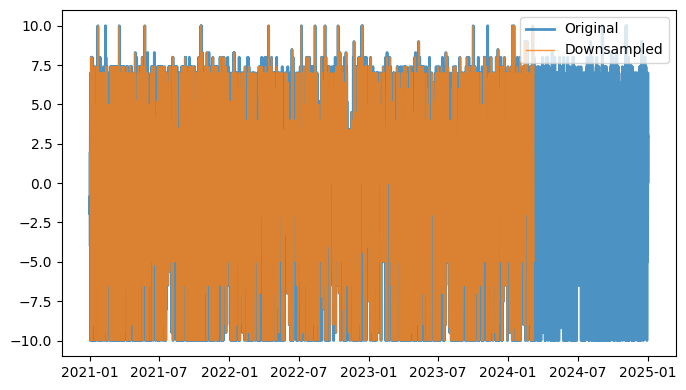

In [16]:
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)

downsampled_train = LTTBDownsampler.downsample_using_lttb_union(df_train, time_col=time_col_name,
                                                                max_points_per_col=len(df_train) // 10)
# downsampled_train = LTTBDownsampler.downsample_using_lttb_intersection(df_train, time_col=time_col_name,
#                                                                 max_points_per_col=len(df_train) // 2)
# downsampled_train = LTTBDownsampler.downsample_lttb_union_with_spikes(df, time_col=time_col_name,
#                                                                       max_points_per_col=len(df) // 10,
#                                                                       spike_thresh=3, spike_method='mad')
# downsampled_train = OtherDownsamplers.downsample_using_rdp_union(df, time_col=time_col_name, epsilon=0.5)
# downsampled_train = OtherDownsamplers.downsample_using_vw_union(df, time_col=time_col_name, target_points=len(df)//2)
# downsampled_train = OtherDownsamplers.subsample_timeseries(df_train, subsampling_ratio=100)
# downsampled_train = OtherDownsamplers.get_last_N_rows(df_train, N_rows=5)

# rmse, nrmse = train_and_evaluate_model(df)
# print(f"orig. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

rmse, nrmse = train_and_evaluate_model(df_train, df_test)
print(f"Original train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

rmse, nrmse = train_and_evaluate_model(downsampled_train, df_test)
print(f"data compressed {len(df_train)/len(downsampled_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

df_plotter(df, downsampled_train, 1, time_col_name)


In [17]:
"""Make scatterplot of compressions vs rmse"""
compression_ratio_list, rmse_list, nrmse_list = [], [], []
new_points_per_col_ratio = list(range(2, 10, 8))
new_points_per_col = [int(len(df) / ratio) for ratio in new_points_per_col_ratio]

for i, point_n in enumerate(new_points_per_col):
    compression_ratio_list, rmse_list, nrmse_list = downsample_and_evaluate(
        df, point_n, compression_ratio_list, rmse_list, nrmse_list, rdp_epsilon=0.1, method="union_rdp")

rmse, nrmse = train_and_evaluate_model(df)

plt.figure(figsize=(8, 5))
# plt.scatter(compression_ratio_list, nrmse_list, label="Norm. RMSE", marker="o")
# plt.scatter(1, nrmse, label="original")

plt.scatter(compression_ratio_list, rmse_list, label="RMSE", marker="x")
plt.scatter(1, rmse, label="original")

plt.xlabel("Compression Ratio")
plt.ylabel("RMS error")
plt.title("Error vs Compression Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

TypeError: train_and_evaluate_model() missing 1 required positional argument: 'test_df'

In [ ]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

def plot_corr_matrix(df: pd.DataFrame, title: str = "Feature Correlation Matrix") -> None:
    """Plot heatmap of Pearson correlation matrix for the DataFrame features"""
    corr = df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_autocorr(series: pd.Series, lags: int = 40, title: str = None) -> None:
    """Plot autocorrelation function (ACF) for a pandas Series"""
    plt.figure(figsize=(8, 4))
    plot_acf(series.dropna(), lags=lags, alpha=0.05)
    plt.title(title or f"Autocorrelation (up to {lags} lags)")
    plt.tight_layout()
    plt.show()

# plot_corr_matrix(df)
# plot_corr_matrix(df_downsampled)
# plot_corr_matrix(df_downsampled2)

plot_autocorr(df['act_still'], lags=10)
plot_autocorr(df_downsampled['act_still'], lags=10)
plot_autocorr(df_downsampled2['act_still'], lags=10)

In [ ]:
"""LSTM"""
# ===== Example usage =====
n_samples  = 100
n_rows     = 10
n_features = 15
X = torch.randn(n_samples, n_rows, n_features)
y = torch.randn(n_samples, 1)

# Train/val split
train_X, val_X = X[:80], X[80:]
train_y, val_y = y[:80], y[80:]

# Model/optimizer/loss
model     = LSTMModel(input_size=n_features, hidden_size=64, num_layers=2, output_size=1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
trainer = LSTMTrainer(model, optimizer, criterion)
trainer.fit(train_X, train_y, val_X, val_y, epochs=300)

# Inference
new_seq    = torch.randn(1, n_rows, n_features)  # batch=1, seq=10, features=15
prediction = trainer.predict(new_seq)
print("Prediction:", prediction)
